In [35]:
!pip list | grep qiskit
# !pip install --upgrade pip
# !pip uninstall qiskit -y
# !pip uninstall qiskit qiskit-aer qiskit-ibmq-provider qiskit-terra -y
# !rm -rf /opt/homebrew/lib/python3.10/site-packages/qiskit
# !pip list | grep qiskit
# !conda remove -n qiskit_env --all
# !pip install qiskit-terra
# !pip install qiskit-aer
# !pip install qiskit-ibmq-provider
# !pip install qiskit-terra==0.46.3 
# !pip install qiskit-ibmq-provider==0.20.2
# !pip install qiskit-aer==0.17.2
# !pip install -U qiskit
# !pip install 'qiskit[visualization]'
# !pip install numpy
# !pip install qiskit-algorithms


zsh:1: /Users/meghadeepa/Documents/Quantum_computing/Q_computing_project/.venv/bin/pip: bad interpreter: /Users/meghadeepa/Documents/Q_computing_project/.venv/bin/python3: no such file or directory
qiskit                            2.4.1
qiskit-aer                        0.17.2


In [41]:
# import sys
# print(sys.executable)  # Which Python is running in this kernel?
# # Check what's actually installed in THIS kernel's environment
# import subprocess
# result = subprocess.run([sys.executable, '-m', 'pip', 'list'], capture_output=True, text=True)
# print(result.stdout)
# import sys
# !{sys.executable} -m pip install qiskit-aer

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
# from qiskit_aer import AerSimulator
# from qiskit.visualization import plot_histogram

In [4]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

{'00': 508, '11': 516}


In [ ]:
counts = result[0].data.meas.get_counts()
plot_histogram(counts)

In [ ]:
counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}

data = [counts1, counts2]
plot_histogram(data)

In [6]:
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])

In [36]:
# !pip install qiskit --upgrade

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import TimeEvolutionProblem
from qiskit.circuit.library import PauliEvolutionGate

In [32]:
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", 1.0),
    ("XI", 0.5)
])

In [17]:
#### Hamiltonian 

def pauli_string(N, ops):
    """
    N: number of qubits
    ops: dict like {qubit_index: 'X'/'Y'/'Z'}
    """
    s = ["I"] * N
    for qubit, op in ops.items():
        s[qubit] = op
    return "".join(s)


def build_J(N, a):
    
    positions = list(range(N)) 
    J = {}

    for i in range(N):
        for j in range(i + 1, N):
            dist = abs(positions[i] - positions[j])
            d_pbc = min(dist, N - dist)   # key line for PBC
            J[(i, j)] = 1.0 / (d_pbc ** a)

    return J


terms = []

# X fields
N=4
h=1.436
a=3.0
J=build_J(N, a)
for i in range(N):
    terms.append((pauli_string(N, {i: "X"}), h))

# ZZ interactions
for (i, j), val in J.items():
    terms.append((pauli_string(N, {i: "Z", j: "Z"}), val))
    
print(terms)   
hamiltonian = SparsePauliOp.from_list(terms) 

[('XIII', 1.436), ('IXII', 1.436), ('IIXI', 1.436), ('IIIX', 1.436), ('ZZII', 1.0), ('ZIZI', 0.125), ('ZIIZ', 1.0), ('IZZI', 1.0), ('IZIZ', 0.125), ('IIZZ', 1.0)]


In [ ]:
### using Lie-Trotter to synthesize the evolution gate for the Hamiltonian ###
from qiskit.synthesis import LieTrotter

evolution_gate = PauliEvolutionGate(
    hamiltonian,
    time=1.0,
    synthesis=LieTrotter(reps=20)
)

# print(evolution_gate.operator)
## application of the circuit to qbits  and visualization##
qc = QuantumCircuit(N)
qc.append(evolution_gate, list(range(N)))

de_circuit=qc.decompose().draw("mpl")

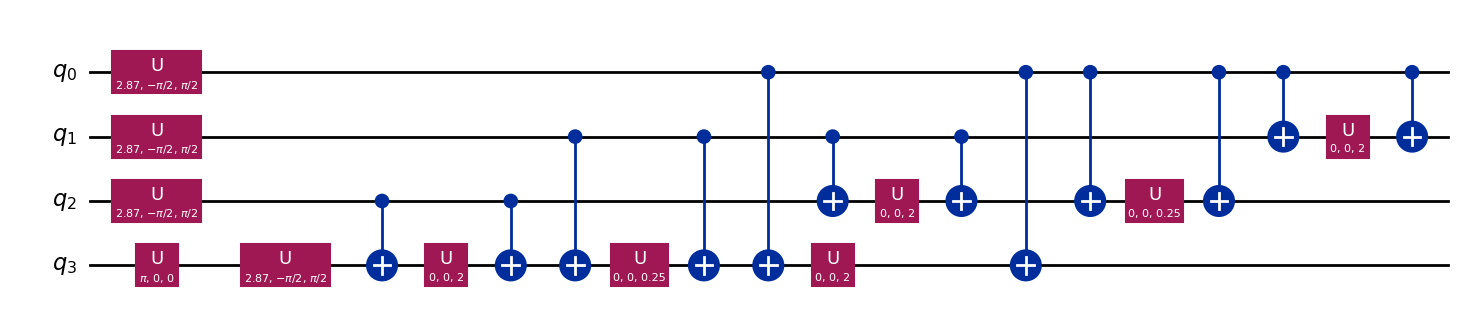

In [23]:
###--- time evolution of an initial state through a time independent Hamiltonian
# using TrotterQRTE Trotterization--###
from qiskit.quantum_info import Statevector
from qiskit_algorithms import TrotterQRTE
initial_state = Statevector.from_label("1000")
problem = TimeEvolutionProblem(hamiltonian, initial_state=initial_state, time=1.0)
trotter = TrotterQRTE()
result = trotter.evolve(problem)

# circuit = result.evolved_state.draw("mpl")
de_circuit=result.evolved_state.decompose(reps=10).decompose("disentangler_dg").decompose(
    "multiplex1_reverse_dg"
).draw("mpl")

In [44]:
### ---- trotterization manually by decomposing the evolution operator 
# into exponentials of the individual terms in the Hamiltonian
# and then applying the Lie-Trotter formula to approximate the
# evolution operator as a product of exponentials of the individual terms.

from qiskit_aer import AerSimulator
def xx_evolution(qc, q0, q1, theta):
    """Implements exp(-i * theta * X⊗X)"""
    qc.h(q0)
    qc.h(q1)
    qc.cx(q0, q1)
    qc.rz(2 * theta, q1)
    qc.cx(q0, q1)
    qc.h(q0)
    qc.h(q1)

def yy_evolution(qc, q0, q1, theta):
    """Implements exp(-i * theta * Y⊗Y)"""
    qc.sdg(q0); qc.h(q0)
    qc.sdg(q1); qc.h(q1)
    qc.cx(q0, q1)
    qc.rz(2 * theta, q1)
    qc.cx(q0, q1)
    qc.h(q0); qc.s(q0)
    qc.h(q1); qc.s(q1)

def zz_evolution(qc, q0, q1, theta):
    """Implements exp(-i * theta * Z⊗Z)"""
    qc.cx(q0, q1)
    qc.rz(2 * theta, q1)
    qc.cx(q0, q1)

In [ ]:
"""
def set_plotting_parameters():
    rc('text', usetex=True)
    mpl.rcParams['pdf.fonttype'] = 42
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['ps.fonttype'] = 42
    global fs
    global lw
    fs = 20
    lw = 3
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['xtick.major.size'] = 10
    mpl.rcParams['xtick.major.width'] = 1
    mpl.rcParams['ytick.major.size'] = 10
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['xtick.minor.size'] = 5
    mpl.rcParams['xtick.minor.width'] = 1
    mpl.rcParams['ytick.minor.size'] = 5
    mpl.rcParams['ytick.minor.width'] = 1
    mpl.rcParams['lines.linewidth'] = lw
    plt.rcParams['axes.facecolor'] = 'white'
    mpl.rc('xtick', labelsize=fs)
    mpl.rc('ytick', labelsize=fs)
    mpl.rcParams.update({'font.size': fs})
    mpl.rcParams.update({'font.weight': 'bold'})
    print('Plotting Parameters Set')
    """